In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('../data/OnlineRetail.csv', encoding='latin1')

In [3]:
df = data.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype("str")

In [8]:
df = df.drop_duplicates(subset=['InvoiceNo', 'StockCode', 'InvoiceDate', 'Quantity'])

In [9]:
df_cohort = df.copy()

In [10]:
df_cohort['InvoiceMonth'] = df_cohort['InvoiceDate'].dt.to_period('M')

cohort = df_cohort.groupby('CustomerID')['InvoiceMonth'].min().reset_index()
cohort.columns = ['CustomerID', 'CohortMonth']

df_cohort = df_cohort.merge(cohort, on='CustomerID')

In [11]:
def get_month_diff(d1, d2):
    return (d2.year - d1.year) * 12 + (d2.month - d1.month)

df_cohort['CohortIndex'] = df_cohort.apply(
    lambda x: get_month_diff(x['CohortMonth'], x['InvoiceMonth']) + 1, axis=1)

In [12]:
cohort_data = (
    df_cohort.groupby(['CohortMonth', 'CohortIndex'])['CustomerID']
    .nunique()
    .reset_index()
)

cohort_counts = cohort_data.pivot(index='CohortMonth', 
                                columns='CohortIndex',
                                values='CustomerID')

In [13]:
cohort_size = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_size, axis=0)

In [14]:
cohort_data = (
    df_cohort.groupby(['CohortMonth', 'CohortIndex'])['CustomerID']
    .nunique()
    .reset_index()
)

cohort_counts = cohort_data.pivot(index='CohortMonth', 
                                columns='CohortIndex', 
                                values='CustomerID')

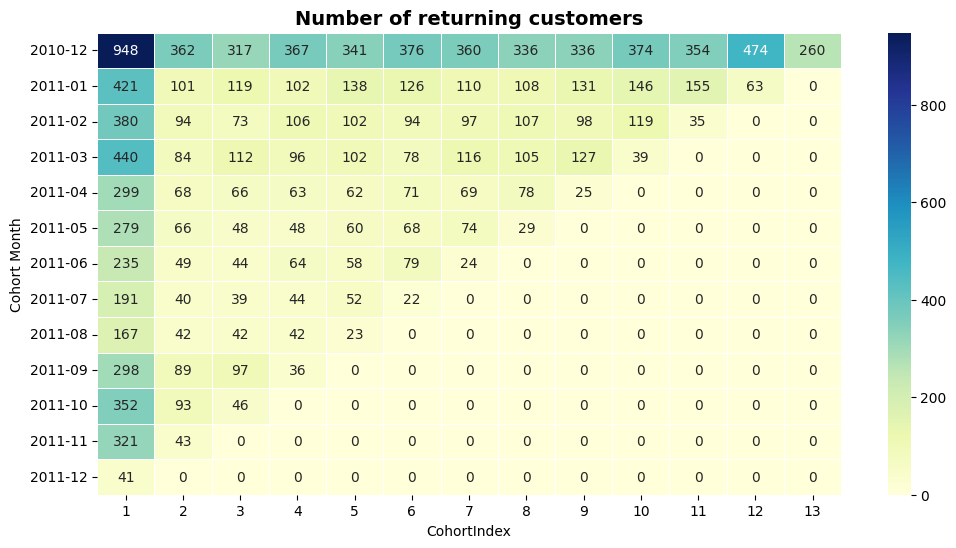

In [15]:
cohort_counts_int = cohort_counts.fillna(0).astype(int)

plt.figure(figsize=(12, 6))
sns.heatmap(
    cohort_counts_int,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
    fmt = "d"
)
plt.title("Number of returning customers", fontsize=14, fontweight='bold')
plt.ylabel("Cohort Month")
plt.yticks(rotation=0)
plt.savefig("image/Number of returning customers.png")
plt.show()

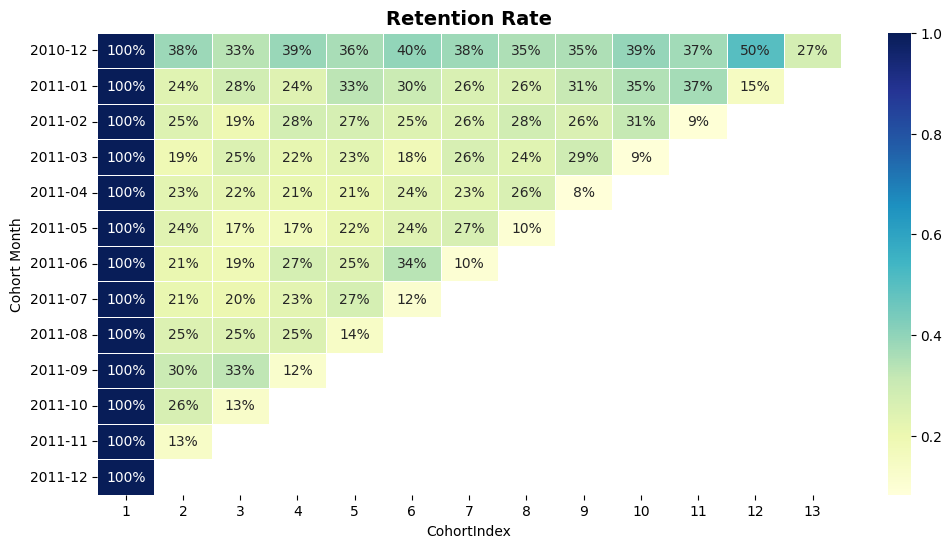

In [16]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Retention Rate", fontsize=14, fontweight='bold')
plt.ylabel("Cohort Month")
plt.yticks(rotation=0)
plt.savefig("image/Retention Rate.png")
plt.show()

In [17]:
#end